In [1]:
import pandas as pd

In [7]:
df = pd.read_excel("prehoc_xai_loan_dataset.xlsx")

In [8]:
df.head()

,age,gender,marital_status,education,occupation,annual_income,credit_score,years_with_employer,pin_code,property_area,loan_amount,previous_default,loan_approved
0,36,Male,Married,High School,Engineer,837876,689,4,560002,Semi-Urban,796400,No,Yes
1,24,Female,Single,UG,Teacher,459429,703,7,560021,Semi-Urban,506593,No,No
2,38,Female,Single,High School,Clerk,630392,676,5,560021,Semi-Urban,350830,No,No
3,39,Male,Married,UG,Technician,429158,635,6,560003,Semi-Urban,1017953,No,No
4,39,Male,Single,PG,Technician,377778,668,12,560001,Urban,1008111,No,Yes


In [9]:
contigecy_table = pd.crosstab(df['gender'],df['loan_approved'])
contigecy_table

loan_approved,No,Yes
gender,,
Female,323,6
Male,85,586


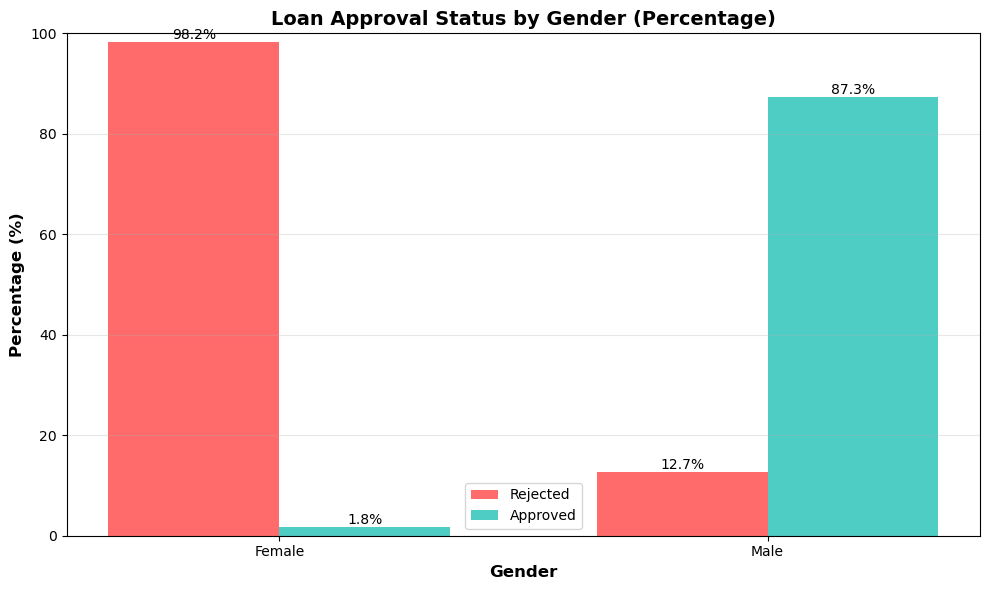


Percentage breakdown:
loan_approved         No        Yes
gender                             
Female         98.176292   1.823708
Male           12.667660  87.332340


In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate percentages by gender
percentage_table = contigecy_table.div(contigecy_table.sum(axis=1), axis=0) * 100

# Create a grouped bar chart
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(percentage_table.index))
width = 0.35

bars1 = ax.bar(x - width/2, percentage_table.iloc[:, 0], width, label='Rejected', color='#FF6B6B')
bars2 = ax.bar(x + width/2, percentage_table.iloc[:, 1], width, label='Approved', color='#4ECDC4')

ax.set_xlabel('Gender', fontsize=12, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
ax.set_title('Loan Approval Status by Gender (Percentage)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(percentage_table.index)
ax.legend()
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)

# Add percentage labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%',
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Also print the percentage table for reference
print("\nPercentage breakdown:")
print(percentage_table)

In [11]:
print(df.columns)
print(df.head())
print(df['Annual_Income'].describe() if 'Annual_Income' in df.columns else "Income column info")

Index(['age', 'gender', 'marital_status', 'education', 'occupation',
       'annual_income', 'credit_score', 'years_with_employer', 'pin_code',
       'property_area', 'loan_amount', 'previous_default', 'loan_approved'],
      dtype='object')
   age  gender marital_status    education  occupation  annual_income  \
0   36    Male        Married  High School    Engineer         837876   
1   24  Female         Single           UG     Teacher         459429   
2   38  Female         Single  High School       Clerk         630392   
3   39    Male        Married           UG  Technician         429158   
4   39    Male         Single           PG  Technician         377778   

   credit_score  years_with_employer  pin_code property_area  loan_amount  \
0           689                    4    560002    Semi-Urban       796400   
1           703                    7    560021    Semi-Urban       506593   
2           676                    5    560021    Semi-Urban       350830   
3         

Approval percentage by income range and gender:
gender          Female       Male
income_range                     
Very Low      0.000000  63.076923
Low           2.873563  70.247934
Medium        3.846154  93.908629
High               NaN  95.833333
Very High          NaN  94.444444


C:\Users\yashb\AppData\Local\Temp\ipykernel_121872\3703558634.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  approval_by_income_gender = df.groupby(['income_range', 'gender']).apply(
C:\Users\yashb\AppData\Local\Temp\ipykernel_121872\3703558634.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  approval_by_income_gender = df.groupby(['income_range', 'gender']).apply(


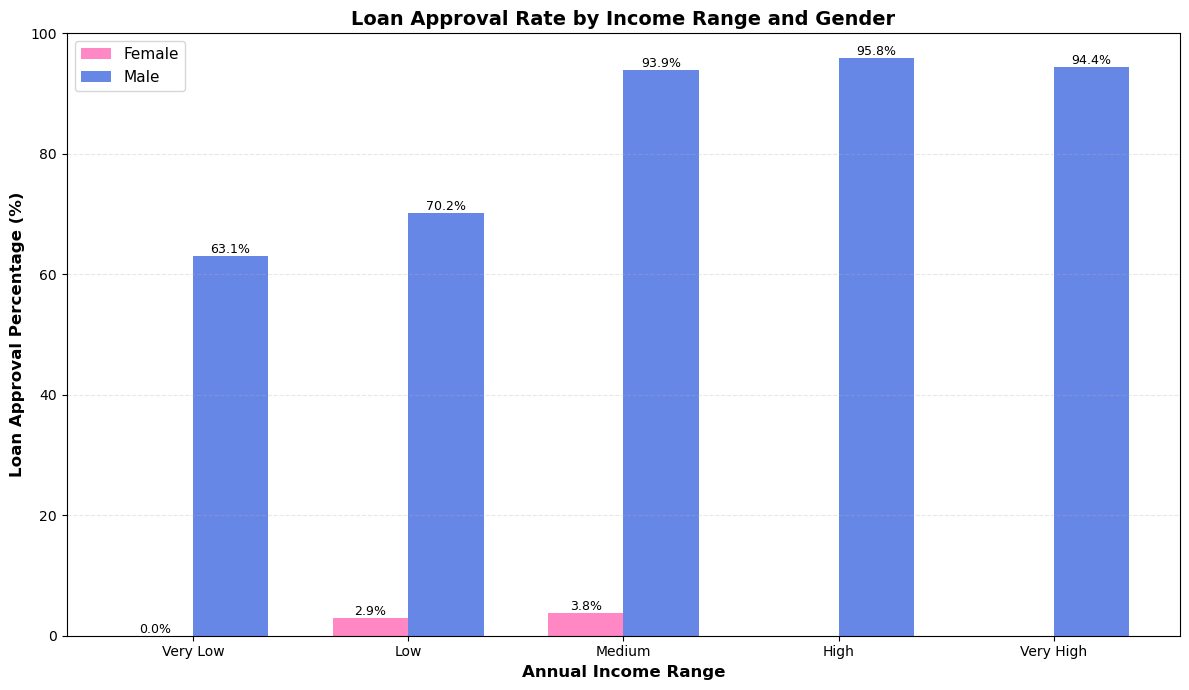

In [12]:
# Create income ranges
df['income_range'] = pd.cut(df['annual_income'], bins=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])

# Calculate approval percentage by income range and gender
approval_by_income_gender = df.groupby(['income_range', 'gender']).apply(
    lambda x: (x['loan_approved'] == 'Yes').sum() / len(x) * 100
).unstack()

print("Approval percentage by income range and gender:")
print(approval_by_income_gender)

# Create the plot
fig, ax = plt.subplots(figsize=(12, 7))

x = np.arange(len(approval_by_income_gender.index))
width = 0.35

# Plot data points for males and females
bars1 = ax.bar(x - width/2, approval_by_income_gender['Female'], width, 
               label='Female', color='#FF69B4', alpha=0.8)
bars2 = ax.bar(x + width/2, approval_by_income_gender['Male'], width, 
               label='Male', color='#4169E1', alpha=0.8)

ax.set_xlabel('Annual Income Range', fontsize=12, fontweight='bold')
ax.set_ylabel('Loan Approval Percentage (%)', fontsize=12, fontweight='bold')
ax.set_title('Loan Approval Rate by Income Range and Gender', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(approval_by_income_gender.index)
ax.legend(fontsize=11)
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add percentage labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [18]:
# Pincode wise analysis
# First, calculate loan to income ratio
df['loan_to_income_ratio'] = df['loan_amount'] / df['annual_income']

pincode_analysis = df.groupby('pin_code').agg({
    'gender': lambda x: (x == 'Male').sum(),  # Count of males
    'marital_status': lambda x: (x == 'Married').sum(),  # Count of married
    'annual_income': ['mean', 'median'],
    'credit_score': 'mean',
    'loan_approved': lambda x: (x == 'Yes').sum() / len(x) * 100,  # Approval rate
    'loan_to_income_ratio': 'mean',  # Average loan to income ratio
    'property_area': lambda x: x.mode()[0] if not x.mode().empty else 'Unknown',  # Most common property area
    'education': lambda x: x.mode()[0] if not x.mode().empty else 'Unknown',  # Most common education
    'age': 'count'  # Total count
})

# Flatten column names
pincode_analysis.columns = ['Males', 'Married', 'Avg_Income', 'Median_Income', 'Avg_CreditScore', 
                            'Loan_Approval_Rate', 'Avg_LoanToIncomeRatio', 'Common_PropertyArea', 'Common_Education', 'Total']

# Calculate females and singles
pincode_analysis['Females'] = pincode_analysis['Total'] - pincode_analysis['Males']
pincode_analysis['Single'] = pincode_analysis['Total'] - pincode_analysis['Married']

# Reorder columns for better readability
pincode_analysis = pincode_analysis[['Total', 'Males', 'Females', 'Married', 'Single', 'Avg_Income', 'Median_Income', 
                                      'Avg_CreditScore', 'Loan_Approval_Rate', 'Avg_LoanToIncomeRatio', 
                                      'Common_PropertyArea', 'Common_Education']]

print("Pincode wise Analysis:")
print(pincode_analysis.round(2))
print(f"\nTotal unique pincodes: {len(pincode_analysis)}")

Pincode wise Analysis:
          Total  Males  Females  Married  Single  Avg_Income  Median_Income  \
pin_code                                                                      
560001      202    202        0      104      98   834269.12       870351.0   
560002      204    204        0      111      93   823159.76       867070.0   
560003      132    132        0       73      59   824991.60       819549.5   
560010      133    133        0       72      61   822231.76       855278.0   
560020      125      0      125       59      66   474784.50       463289.0   
560021       99      0       99       54      45   461138.24       467092.0   
560022       75      0       75       34      41   486502.31       479193.0   
560030       30      0       30       18      12   467133.10       485822.5   

          Avg_CreditScore  Loan_Approval_Rate  Avg_LoanToIncomeRatio  \
pin_code                                                               
560001             671.94               89

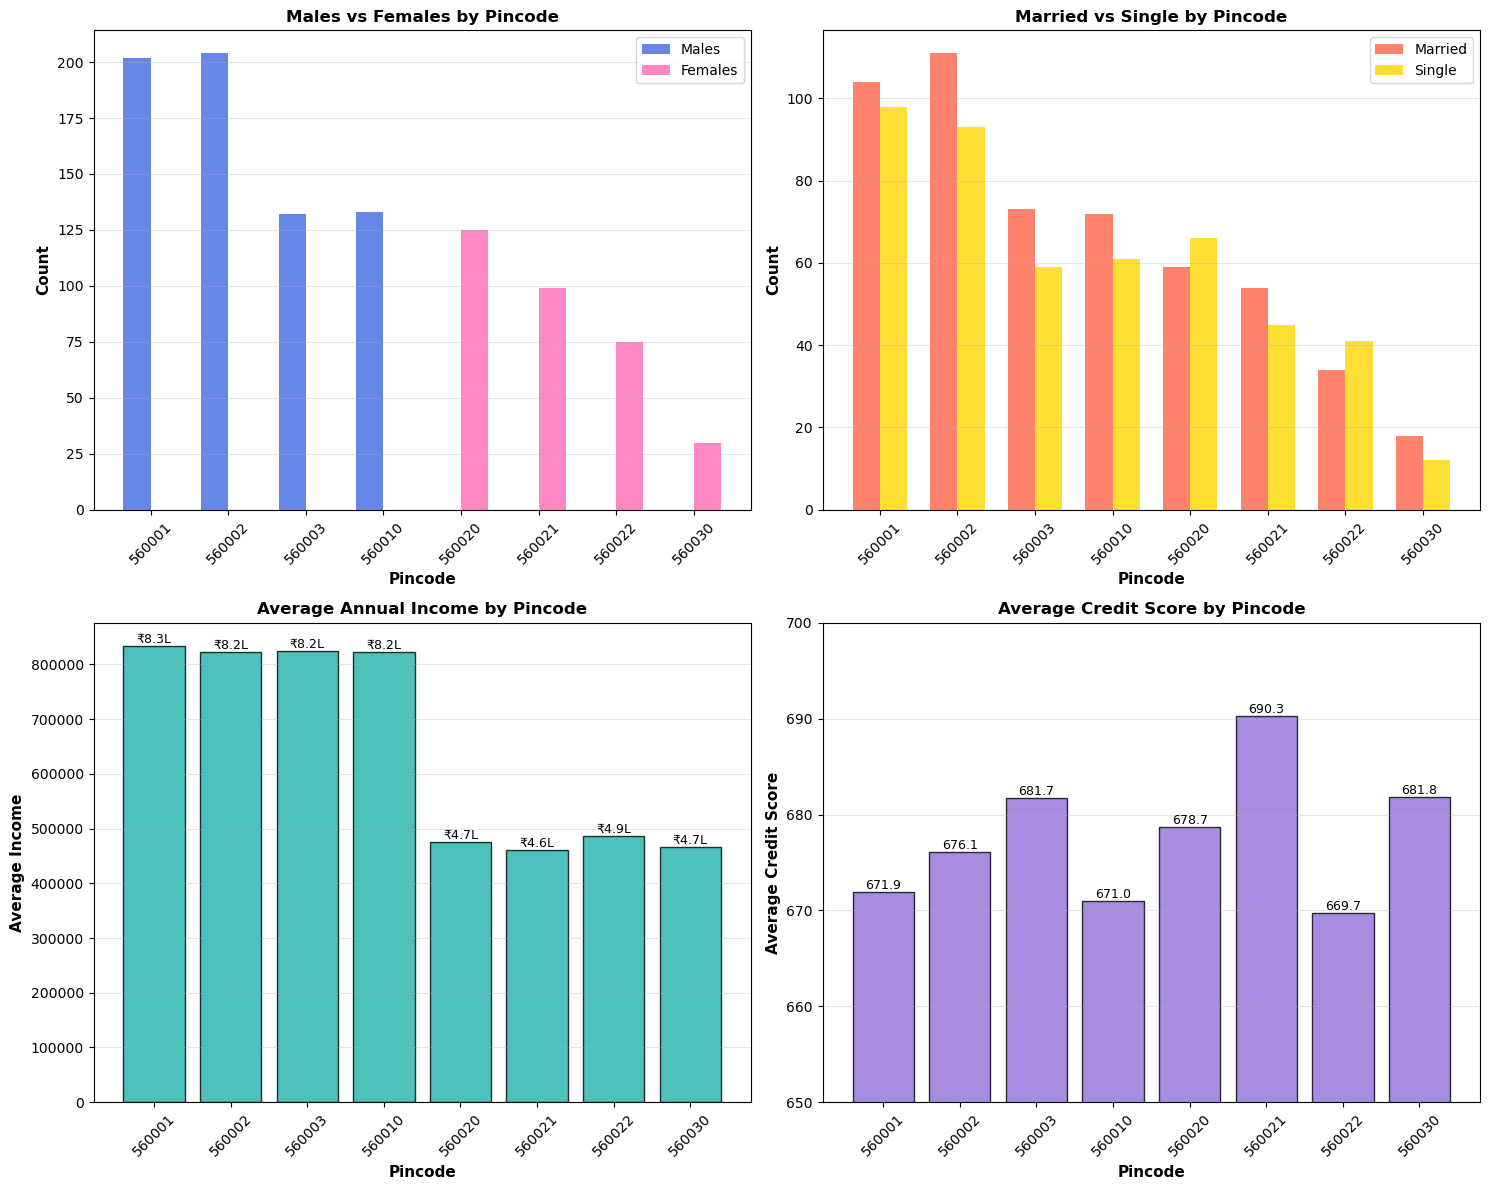

In [15]:
# Create subplots for comprehensive pincode analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

pincodes = pincode_analysis.index.astype(str)
x_pos = np.arange(len(pincodes))
width = 0.35

# Plot 1: Males vs Females by Pincode
ax1 = axes[0, 0]
bars1 = ax1.bar(x_pos - width/2, pincode_analysis['Males'], width, label='Males', color='#4169E1', alpha=0.8)
bars2 = ax1.bar(x_pos + width/2, pincode_analysis['Females'], width, label='Females', color='#FF69B4', alpha=0.8)
ax1.set_xlabel('Pincode', fontsize=11, fontweight='bold')
ax1.set_ylabel('Count', fontsize=11, fontweight='bold')
ax1.set_title('Males vs Females by Pincode', fontsize=12, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(pincodes, rotation=45)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Married vs Single by Pincode
ax2 = axes[0, 1]
bars3 = ax2.bar(x_pos - width/2, pincode_analysis['Married'], width, label='Married', color='#FF6347', alpha=0.8)
bars4 = ax2.bar(x_pos + width/2, pincode_analysis['Single'], width, label='Single', color='#FFD700', alpha=0.8)
ax2.set_xlabel('Pincode', fontsize=11, fontweight='bold')
ax2.set_ylabel('Count', fontsize=11, fontweight='bold')
ax2.set_title('Married vs Single by Pincode', fontsize=12, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(pincodes, rotation=45)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Plot 3: Average Income by Pincode
ax3 = axes[1, 0]
bars5 = ax3.bar(x_pos, pincode_analysis['Avg_Income'], color='#20B2AA', alpha=0.8, edgecolor='black')
ax3.set_xlabel('Pincode', fontsize=11, fontweight='bold')
ax3.set_ylabel('Average Income', fontsize=11, fontweight='bold')
ax3.set_title('Average Annual Income by Pincode', fontsize=12, fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(pincodes, rotation=45)
ax3.grid(axis='y', alpha=0.3)

# Add value labels
for i, (idx, val) in enumerate(zip(x_pos, pincode_analysis['Avg_Income'])):
    ax3.text(idx, val, f'₹{val/1e5:.1f}L', ha='center', va='bottom', fontsize=9)

# Plot 4: Average Credit Score by Pincode
ax4 = axes[1, 1]
bars6 = ax4.bar(x_pos, pincode_analysis['Avg_CreditScore'], color='#9370DB', alpha=0.8, edgecolor='black')
ax4.set_xlabel('Pincode', fontsize=11, fontweight='bold')
ax4.set_ylabel('Average Credit Score', fontsize=11, fontweight='bold')
ax4.set_title('Average Credit Score by Pincode', fontsize=12, fontweight='bold')
ax4.set_xticks(x_pos)
ax4.set_xticklabels(pincodes, rotation=45)
ax4.set_ylim(650, 700)
ax4.grid(axis='y', alpha=0.3)

# Add value labels
for i, (idx, val) in enumerate(zip(x_pos, pincode_analysis['Avg_CreditScore'])):
    ax4.text(idx, val, f'{val:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
# This cell is kept for data processing only - no output needed

Pincode wise Analysis (Updated with Median Income and Loan Approval):
          Total  Males  Females  Married  Single  Avg_Income  Median_Income  \
pin_code                                                                      
560001      202    202        0      104      98   834269.12       870351.0   
560002      204    204        0      111      93   823159.76       867070.0   
560003      132    132        0       73      59   824991.60       819549.5   
560010      133    133        0       72      61   822231.76       855278.0   
560020      125      0      125       59      66   474784.50       463289.0   
560021       99      0       99       54      45   461138.24       467092.0   
560022       75      0       75       34      41   486502.31       479193.0   
560030       30      0       30       18      12   467133.10       485822.5   

          Avg_CreditScore  Loan_Approval_Rate  
pin_code                                       
560001             671.94               89.

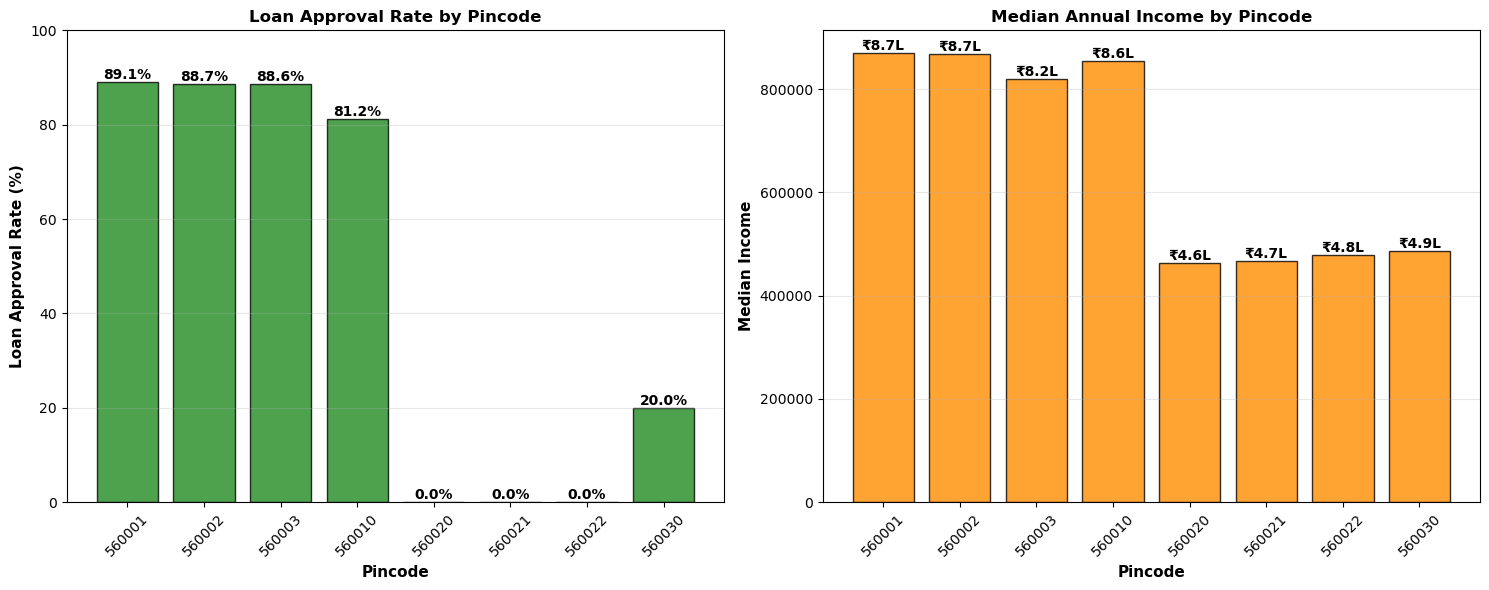

In [17]:
# Create additional subplots for Loan Approval Rate and Median Income
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

pincodes = pincode_analysis.index.astype(str)
x_pos = np.arange(len(pincodes))

# Plot 1: Loan Approval Rate by Pincode
ax1 = axes[0]
bars1 = ax1.bar(x_pos, pincode_analysis['Loan_Approval_Rate'], color='#228B22', alpha=0.8, edgecolor='black')
ax1.set_xlabel('Pincode', fontsize=11, fontweight='bold')
ax1.set_ylabel('Loan Approval Rate (%)', fontsize=11, fontweight='bold')
ax1.set_title('Loan Approval Rate by Pincode', fontsize=12, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(pincodes, rotation=45)
ax1.set_ylim(0, 100)
ax1.grid(axis='y', alpha=0.3)

# Add value labels
for i, (idx, val) in enumerate(zip(x_pos, pincode_analysis['Loan_Approval_Rate'])):
    ax1.text(idx, val, f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 2: Median Income by Pincode
ax2 = axes[1]
bars2 = ax2.bar(x_pos, pincode_analysis['Median_Income'], color='#FF8C00', alpha=0.8, edgecolor='black')
ax2.set_xlabel('Pincode', fontsize=11, fontweight='bold')
ax2.set_ylabel('Median Income', fontsize=11, fontweight='bold')
ax2.set_title('Median Annual Income by Pincode', fontsize=12, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(pincodes, rotation=45)
ax2.grid(axis='y', alpha=0.3)

# Add value labels
for i, (idx, val) in enumerate(zip(x_pos, pincode_analysis['Median_Income'])):
    ax2.text(idx, val, f'₹{val/1e5:.1f}L', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

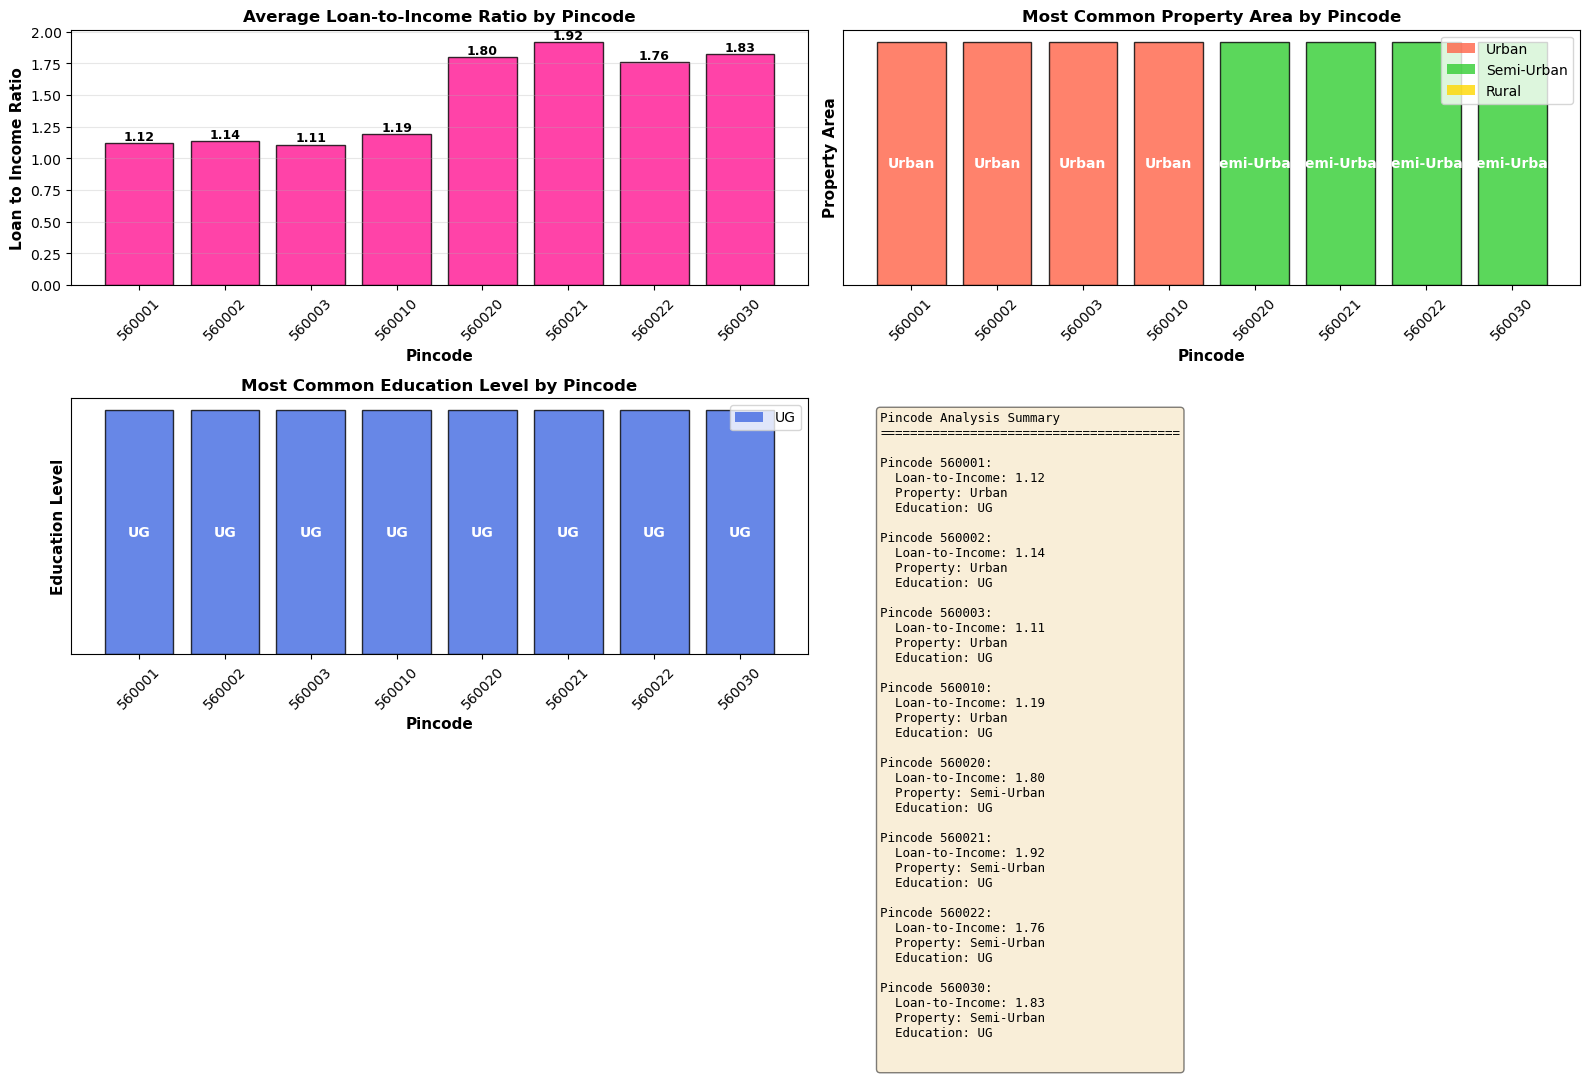

In [19]:
# Create visualizations for Loan-to-Income Ratio and Property Area/Education
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

pincodes = pincode_analysis.index.astype(str)
x_pos = np.arange(len(pincodes))

# Plot 1: Loan to Income Ratio by Pincode
ax1 = axes[0, 0]
bars1 = ax1.bar(x_pos, pincode_analysis['Avg_LoanToIncomeRatio'], color='#FF1493', alpha=0.8, edgecolor='black')
ax1.set_xlabel('Pincode', fontsize=11, fontweight='bold')
ax1.set_ylabel('Loan to Income Ratio', fontsize=11, fontweight='bold')
ax1.set_title('Average Loan-to-Income Ratio by Pincode', fontsize=12, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(pincodes, rotation=45)
ax1.grid(axis='y', alpha=0.3)

# Add value labels
for i, (idx, val) in enumerate(zip(x_pos, pincode_analysis['Avg_LoanToIncomeRatio'])):
    ax1.text(idx, val, f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 2: Property Area Distribution by Pincode
ax2 = axes[0, 1]
property_areas = pincode_analysis['Common_PropertyArea'].unique()
property_colors = {'Urban': '#FF6347', 'Semi-Urban': '#32CD32', 'Rural': '#FFD700'}
colors_list = [property_colors.get(area, '#808080') for area in pincode_analysis['Common_PropertyArea']]
bars2 = ax2.bar(x_pos, [1]*len(x_pos), color=colors_list, alpha=0.8, edgecolor='black')
ax2.set_xlabel('Pincode', fontsize=11, fontweight='bold')
ax2.set_ylabel('Property Area', fontsize=11, fontweight='bold')
ax2.set_title('Most Common Property Area by Pincode', fontsize=12, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(pincodes, rotation=45)
ax2.set_yticks([])

# Add area labels on bars
for i, (idx, area) in enumerate(zip(x_pos, pincode_analysis['Common_PropertyArea'])):
    ax2.text(idx, 0.5, area, ha='center', va='center', fontsize=10, fontweight='bold', color='white')

# Create custom legend for property areas
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, alpha=0.8, label=area) for area, color in property_colors.items()]
ax2.legend(handles=legend_elements, loc='upper right')

# Plot 3: Education Distribution by Pincode
ax3 = axes[1, 0]
education_types = pincode_analysis['Common_Education'].unique()
edu_colors = {'High School': '#FF6347', 'UG': '#4169E1', 'PG': '#FFD700', 'Unknown': '#808080'}
colors_list_edu = [edu_colors.get(edu, '#808080') for edu in pincode_analysis['Common_Education']]
bars3 = ax3.bar(x_pos, [1]*len(x_pos), color=colors_list_edu, alpha=0.8, edgecolor='black')
ax3.set_xlabel('Pincode', fontsize=11, fontweight='bold')
ax3.set_ylabel('Education Level', fontsize=11, fontweight='bold')
ax3.set_title('Most Common Education Level by Pincode', fontsize=12, fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(pincodes, rotation=45)
ax3.set_yticks([])

# Add education labels on bars
for i, (idx, edu) in enumerate(zip(x_pos, pincode_analysis['Common_Education'])):
    ax3.text(idx, 0.5, edu, ha='center', va='center', fontsize=10, fontweight='bold', color='white')

# Create custom legend for education
legend_elements_edu = [Patch(facecolor=color, alpha=0.8, label=edu) for edu, color in edu_colors.items() if edu in pincode_analysis['Common_Education'].values]
ax3.legend(handles=legend_elements_edu, loc='upper right')

# Plot 4: Summary comparison
ax4 = axes[1, 1]
ax4.axis('off')

# Create summary text
summary_text = "Pincode Analysis Summary\n" + "="*40 + "\n\n"
for idx in pincode_analysis.index:
    row = pincode_analysis.loc[idx]
    summary_text += f"Pincode {idx}:\n"
    summary_text += f"  Loan-to-Income: {row['Avg_LoanToIncomeRatio']:.2f}\n"
    summary_text += f"  Property: {row['Common_PropertyArea']}\n"
    summary_text += f"  Education: {row['Common_Education']}\n\n"

ax4.text(0.05, 0.95, summary_text, transform=ax4.transAxes, fontsize=9, 
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

In [20]:
# Filter data for pincode 560030
pincode_560030_data = df[df['pin_code'] == 560030]

print(f"Data for Pincode 560030")
print(f"Total Records: {len(pincode_560030_data)}")
print("\n" + "="*100)
print(pincode_560030_data.to_string())
print("="*100)
print(f"\nSummary Statistics for Pincode 560030:")
print(pincode_560030_data[['age', 'annual_income', 'credit_score', 'loan_amount', 'loan_to_income_ratio']].describe().round(2))

Data for Pincode 560030
Total Records: 30

     age  gender marital_status    education occupation  annual_income  credit_score  years_with_employer  pin_code property_area  loan_amount previous_default loan_approved income_range  loan_to_income_ratio
91    28  Female         Single           PG         HR         647821           684                    2    560030    Semi-Urban       999079               No           Yes          Low              1.542215
113   44  Female        Married           UG      Clerk         370274           730                    3    560030    Semi-Urban      1072036               No            No     Very Low              2.895251
120   37  Female        Married           UG      Clerk         476956           638                    5    560030         Rural       329183               No            No          Low              0.690175
137   36  Female        Married  High School    Teacher         443944           679                    6    560030    Se

In [21]:
# Find data points where only difference is pincode and loan_approved
# Select columns to compare (exclude pincode and loan_approved)
comparison_cols = [col for col in df.columns if col not in ['pin_code', 'loan_approved']]

print("Finding data points with same attributes but different pincode and/or loan_approved status...")
print("="*120)

# Create a comparison key from all other columns
df['comparison_key'] = df[comparison_cols].astype(str).agg('_'.join, axis=1)

# Find groups with the same comparison key (same attributes except pincode and loan_approved)
duplicate_groups = df.groupby('comparison_key').filter(lambda x: len(x) > 1)

if len(duplicate_groups) > 0:
    # Group by the comparison key to see the variations
    for key, group in df.groupby('comparison_key'):
        if len(group) > 1:
            # Check if variations are only in pincode and/or loan_approved
            group_subset = group[['age', 'gender', 'marital_status', 'education', 'occupation', 
                                   'annual_income', 'credit_score', 'years_with_employer', 
                                   'property_area', 'loan_amount', 'previous_default', 
                                   'pin_code', 'loan_approved']]
            
            # If there are differences in pincode and/or loan_approved
            if group_subset['pin_code'].nunique() > 1 or group_subset['loan_approved'].nunique() > 1:
                print(f"\n{'='*120}")
                print(f"Found {len(group)} matching records (all attributes same except pincode/loan_approved):")
                print('='*120)
                print(group_subset.to_string())
                print()
else:
    print("\nNo exact matches found where only pincode and/or loan_approved differ.")
    print("\nSearching for near-matches (difference in 1-2 other attributes)...")
    print("="*120)
    
    # Alternative: find records with very similar attributes (allowing small differences)
    # Let's find records with same gender, age range, income range, and credit score range
    df['age_range'] = pd.cut(df['age'], bins=[0, 25, 35, 45, 55, 100], labels=['<25', '25-35', '35-45', '45-55', '55+'])
    df['income_range_cat'] = pd.cut(df['annual_income'], bins=5)
    df['credit_score_range'] = pd.cut(df['credit_score'], bins=[0, 650, 700, 750, 800], labels=['<650', '650-700', '700-750', '750+'])
    
    comparison_cols_broad = ['gender', 'age_range', 'marital_status', 'education', 'occupation', 
                             'income_range_cat', 'credit_score_range', 'property_area']
    
    df['comparison_key_broad'] = df[comparison_cols_broad].astype(str).agg('_'.join, axis=1)
    
    duplicate_groups_broad = df.groupby('comparison_key_broad').filter(lambda x: len(x) > 1)
    
    count = 0
    for key, group in df.groupby('comparison_key_broad'):
        if len(group) > 1 and count < 5:  # Show first 5 matches
            group_subset = group[['age', 'gender', 'marital_status', 'education', 'occupation', 
                                   'annual_income', 'credit_score', 'property_area',
                                   'pin_code', 'loan_approved']]
            
            if group_subset['pin_code'].nunique() > 1 or group_subset['loan_approved'].nunique() > 1:
                print(f"\nMatch Group {count+1} ({len(group)} records with similar attributes):")
                print('='*120)
                print(group_subset.to_string())
                count += 1

Finding data points with same attributes but different pincode and/or loan_approved status...

No exact matches found where only pincode and/or loan_approved differ.

Searching for near-matches (difference in 1-2 other attributes)...

Match Group 1 (2 records with similar attributes):
     age  gender marital_status    education occupation  annual_income  credit_score property_area  pin_code loan_approved
116   33  Female        Married  High School      Clerk         356702           585    Semi-Urban    560021            No
159   30  Female        Married  High School      Clerk         406837           568    Semi-Urban    560022            No

Match Group 2 (2 records with similar attributes):
     age  gender marital_status    education occupation  annual_income  credit_score property_area  pin_code loan_approved
69    30  Female        Married  High School    Teacher         479576           710         Rural    560021            No
134   34  Female        Married  High School   

In [23]:
# Occupations vs All Other Features Analysis
print("Occupations in the dataset:")
print(df['occupation'].unique())
print(f"\nTotal unique occupations: {df['occupation'].nunique()}")

# Create a comprehensive analysis
occupation_analysis = df.groupby('occupation').agg({
    'age': ['mean', 'std', 'count'],
    'gender': lambda x: (x == 'Male').sum(),
    'marital_status': lambda x: (x == 'Married').sum(),
    'education': lambda x: x.mode()[0] if not x.mode().empty else 'Unknown',
    'annual_income': ['mean', 'median'],
    'credit_score': ['mean', 'std'],
    'years_with_employer': 'mean',
    'loan_amount': ['mean', 'median'],
    'loan_approved': lambda x: (x == 'Yes').sum() / len(x) * 100,
    'property_area': lambda x: x.mode()[0] if not x.mode().empty else 'Unknown'
}).round(2)

# Flatten columns
occupation_analysis.columns = ['Avg_Age', 'Std_Age', 'Count', 'Males', 'Married', 'Common_Education', 
                                'Avg_Income', 'Median_Income', 'Avg_CreditScore', 'Std_CreditScore',
                                'Avg_YearsEmployed', 'Avg_LoanAmount', 'Median_LoanAmount', 
                                'Loan_Approval_Rate', 'Common_PropertyArea']

print("\nOccupation Analysis Summary:")
print(occupation_analysis)

Occupations in the dataset:
['Engineer' 'Teacher' 'Clerk' 'Technician' 'Driver' 'Manager' 'Nurse' 'HR']

Total unique occupations: 8

Occupation Analysis Summary:
            Avg_Age  Std_Age  Count  Males  Married Common_Education  \
occupation                                                             
Clerk         34.90     7.67     94      0       43               UG   
Driver        35.94     7.10     72     72       35               UG   
Engineer      35.03     7.48    274    274      134               UG   
HR            33.52     7.38     75      0       37               UG   
Manager       35.86     7.23    177    177      101               UG   
Nurse         32.64     8.58     22      0       11               UG   
Teacher       35.35     7.83    138      0       74               UG   
Technician    37.13     8.14    148    148       90               UG   

            Avg_Income  Median_Income  Avg_CreditScore  Std_CreditScore  \
occupation                               

In [ ]:
# Create comprehensive visualizations for Occupations vs Other Features
fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

occupations = df['occupation'].unique()
colors = plt.cm.Set3(np.linspace(0, 1, len(occupations)))
occupation_colors = {occ: colors[i] for i, occ in enumerate(occupations)}

# Plot 1: Count by Occupation
ax1 = fig.add_subplot(gs[0, 0])
occ_counts = df['occupation'].value_counts()
bars = ax1.bar(occ_counts.index, occ_counts.values, color=[occupation_colors[occ] for occ in occ_counts.index], edgecolor='black')
ax1.set_title('Count by Occupation', fontsize=12, fontweight='bold')
ax1.set_ylabel('Count', fontsize=10, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height, f'{int(height)}', ha='center', va='bottom', fontsize=9)

# Plot 2: Average Age by Occupation
ax2 = fig.add_subplot(gs[0, 1])
avg_age = df.groupby('occupation')['age'].mean().sort_values(ascending=False)
bars = ax2.bar(avg_age.index, avg_age.values, color=[occupation_colors[occ] for occ in avg_age.index], edgecolor='black')
ax2.set_title('Average Age by Occupation', fontsize=12, fontweight='bold')
ax2.set_ylabel('Age', fontsize=10, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height, f'{height:.1f}', ha='center', va='bottom', fontsize=9)

# Plot 3: Average Income by Occupation
ax3 = fig.add_subplot(gs[0, 2])
avg_income = df.groupby('occupation')['annual_income'].mean().sort_values(ascending=False)
bars = ax3.bar(avg_income.index, avg_income.values, color=[occupation_colors[occ] for occ in avg_income.index], edgecolor='black')
ax3.set_title('Average Annual Income by Occupation', fontsize=12, fontweight='bold')
ax3.set_ylabel('Income', fontsize=10, fontweight='bold')
ax3.tick_params(axis='x', rotation=45)
for bar in bars:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height, f'₹{height/1e5:.1f}L', ha='center', va='bottom', fontsize=9)

# Plot 4: Average Credit Score by Occupation
ax4 = fig.add_subplot(gs[1, 0])
avg_credit = df.groupby('occupation')['credit_score'].mean().sort_values(ascending=False)
bars = ax4.bar(avg_credit.index, avg_credit.values, color=[occupation_colors[occ] for occ in avg_credit.index], edgecolor='black')
ax4.set_title('Average Credit Score by Occupation', fontsize=12, fontweight='bold')
ax4.set_ylabel('Credit Score', fontsize=10, fontweight='bold')
ax4.tick_params(axis='x', rotation=45)
for bar in bars:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height, f'{height:.0f}', ha='center', va='bottom', fontsize=9)

# Plot 5: Loan Approval Rate by Occupation
ax5 = fig.add_subplot(gs[1, 1])
approval_rate = df.groupby('occupation')['loan_approved'].apply(lambda x: (x == 'Yes').sum() / len(x) * 100).sort_values(ascending=False)
bars = ax5.bar(approval_rate.index, approval_rate.values, color=[occupation_colors[occ] for occ in approval_rate.index], edgecolor='black')
ax5.set_title('Loan Approval Rate by Occupation', fontsize=12, fontweight='bold')
ax5.set_ylabel('Approval Rate (%)', fontsize=10, fontweight='bold')
ax5.set_ylim(0, 100)
ax5.tick_params(axis='x', rotation=45)
for bar in bars:
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height, f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

# Plot 6: Male % by Occupation
ax6 = fig.add_subplot(gs[1, 2])
male_pct = df.groupby('occupation')['gender'].apply(lambda x: (x == 'Male').sum() / len(x) * 100).sort_values(ascending=False)
bars = ax6.bar(male_pct.index, male_pct.values, color=[occupation_colors[occ] for occ in male_pct.index], edgecolor='black')
ax6.set_title('Male Percentage by Occupation', fontsize=12, fontweight='bold')
ax6.set_ylabel('Male %', fontsize=10, fontweight='bold')
ax6.set_ylim(0, 100)
ax6.tick_params(axis='x', rotation=45)
for bar in bars:
    height = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2., height, f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

# Plot 7: Average Loan Amount by Occupation
ax7 = fig.add_subplot(gs[2, 0])
avg_loan = df.groupby('occupation')['loan_amount'].mean().sort_values(ascending=False)
bars = ax7.bar(avg_loan.index, avg_loan.values, color=[occupation_colors[occ] for occ in avg_loan.index], edgecolor='black')
ax7.set_title('Average Loan Amount by Occupation', fontsize=12, fontweight='bold')
ax7.set_ylabel('Loan Amount', fontsize=10, fontweight='bold')
ax7.tick_params(axis='x', rotation=45)
for bar in bars:
    height = bar.get_height()
    ax7.text(bar.get_x() + bar.get_width()/2., height, f'₹{height/1e5:.1f}L', ha='center', va='bottom', fontsize=9)

# Plot 8: Years with Employer by Occupation
ax8 = fig.add_subplot(gs[2, 1])
avg_years = df.groupby('occupation')['years_with_employer'].mean().sort_values(ascending=False)
bars = ax8.bar(avg_years.index, avg_years.values, color=[occupation_colors[occ] for occ in avg_years.index], edgecolor='black')
ax8.set_title('Average Years with Employer by Occupation', fontsize=12, fontweight='bold')
ax8.set_ylabel('Years', fontsize=10, fontweight='bold')
ax8.tick_params(axis='x', rotation=45)
for bar in bars:
    height = bar.get_height()
    ax8.text(bar.get_x() + bar.get_width()/2., height, f'{height:.1f}', ha='center', va='bottom', fontsize=9)

# Plot 9: Married % by Occupation
ax9 = fig.add_subplot(gs[2, 2])
married_pct = df.groupby('occupation')['marital_status'].apply(lambda x: (x == 'Married').sum() / len(x) * 100).sort_values(ascending=False)
bars = ax9.bar(married_pct.index, married_pct.values, color=[occupation_colors[occ] for occ in married_pct.index], edgecolor='black')
ax9.set_title('Married Percentage by Occupation', fontsize=12, fontweight='bold')
ax9.set_ylabel('Married %', fontsize=10, fontweight='bold')
ax9.set_ylim(0, 100)
ax9.tick_params(axis='x', rotation=45)
for bar in bars:
    height = bar.get_height()
    ax9.text(bar.get_x() + bar.get_width()/2., height, f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

plt.suptitle('Occupations vs All Features Analysis', fontsize=16, fontweight='bold', y=0.995)
plt.show()